In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    r"C:\Users\lenovo\OneDrive\Desktop\data science\sample data\twittwer\twitter_training.csv",
    header=None,
    names=["id", "entity", "sentiment", "text"]
)

In [3]:
validation_df = pd.read_csv(
    r"C:\Users\lenovo\OneDrive\Desktop\data science\sample data\twittwer\twitter_validation.csv",
    header=None,
    names=["id", "entity", "sentiment", "text"]
) 

In [4]:
df.head()

,id,entity,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         74682 non-null  int64 
 1   entity     74682 non-null  object
 2   sentiment  74682 non-null  object
 3   text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [6]:
df["sentiment"].value_counts()

sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

In [7]:
df.isnull().sum()

id             0
entity         0
sentiment      0
text         686
dtype: int64

In [8]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [9]:
df = df.dropna(subset=["text"]).copy()

In [19]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def preprocess_text(text):
    text = str(text).lower()
    
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
  
    text = text.translate(str.maketrans("", "", string.punctuation))
 
    tokens = word_tokenize(text)
  
    tokens = [word for word in tokens if word not in stop_words]

    tokens = [stemmer.stem(word) for word in tokens]
    
    return " ".join(tokens)

In [20]:
df["clean_text"] = df["text"].apply(preprocess_text)

In [21]:
df[["text", "clean_text"]].head()

,text,clean_text
0,im getting on borderlands and i will murder yo...,im get borderland murder
1,I am coming to the borders and I will kill you...,come border kill
2,im getting on borderlands and i will kill you ...,im get borderland kill
3,im coming on borderlands and i will murder you...,im come borderland murder
4,im getting on borderlands 2 and i will murder ...,im get borderland 2 murder


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

vectorizer = TfidfVectorizer(
    max_features=10000
)

X = vectorizer.fit_transform(df["clean_text"])
y = df["sentiment"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [34]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (59196, 10000)
Testing data: (14800, 10000)


In [41]:
# Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [42]:
# Logistic Regressionabs
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [48]:
# Naive Bayes evaluation
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(
    y_test, nb_pred, average="weighted"
)

nb_recall = recall_score(
    y_test, nb_pred, average="weighted"
)
nb_f1 = f1_score(
    y_test, nb_pred, average="weighted"
)

In [55]:
# Logistic Regression evaluation 
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(
    y_test, lr_pred, average="weighted"
)
lr_recall = recall_score(
    y_test, lr_pred, average="weighted"
)
lr_f1 = f1_score(
    y_test, lr_pred, average="weighted"
)

In [61]:
# compare
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [nb_accuracy, lr_accuracy],
    "Precision": [nb_precision, lr_precision],
    "Recall": [nb_recall, lr_recall],
    "F1-Score": [nb_f1, lr_f1]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.692568,0.715328,0.692568,0.683595
1,Logistic Regression,0.733986,0.734709,0.733986,0.732627


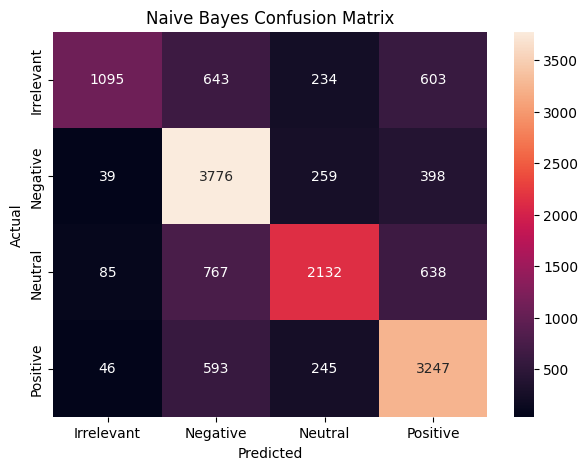

In [67]:
# Naive Bayes confusion
labels = sorted(y.unique())

nb_cm = confusion_matrix(
    y_test,
    nb_pred,
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

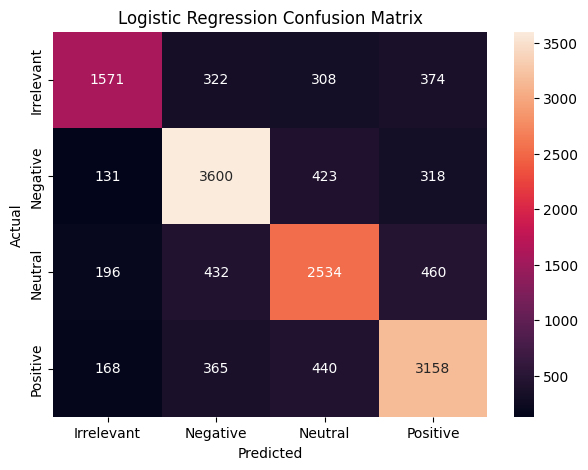

In [72]:
# Logistic Regression confusion 
lr_cm = confusion_matrix(
    y_test,
    lr_pred,
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Visualize Sentiment Distribution and WordCloud

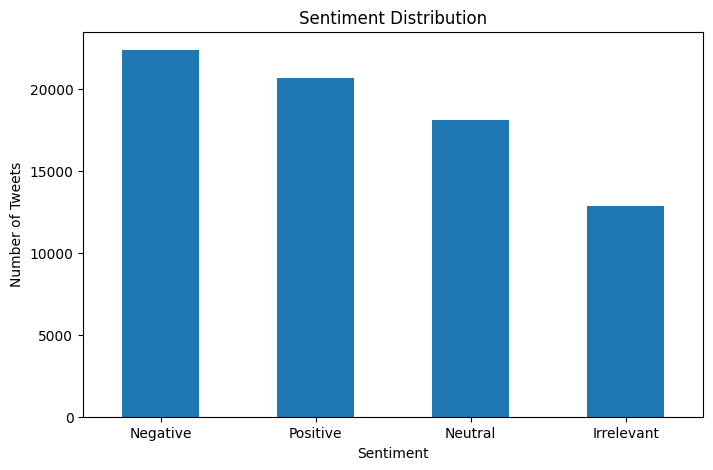

In [76]:
# Sentiment distribution 
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(8, 5))

sentiment_counts.plot(kind="bar")

plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.title("Sentiment Distribution")

plt.xticks(rotation=0)
plt.show()

In [78]:
# WordCloud 
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.5.1-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-2.5.1-cp314-cp314-win_amd64.whl (12.6 MB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 5.1 MB/s eta 0:00:02
   

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
import sys
!{sys.executable} -m pip install wordcloud


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [81]:
from wordcloud import WordCloud

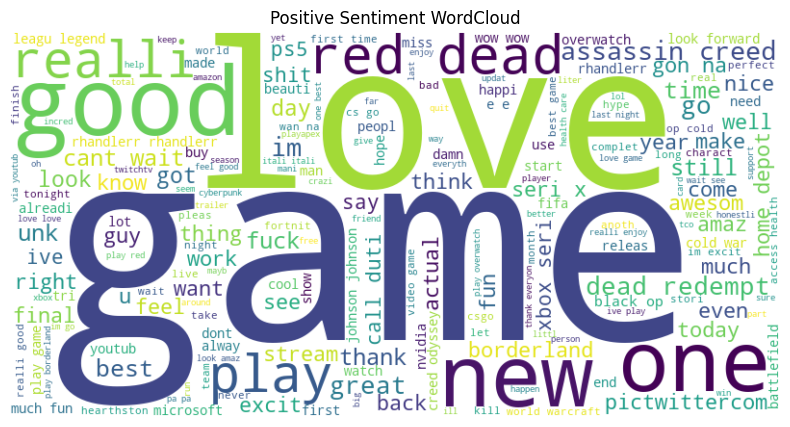

In [87]:
# Positive 
positive_text = " ".join(
    df[df["sentiment"] == "Positive"]["clean_text"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Sentiment WordCloud")
plt.show()

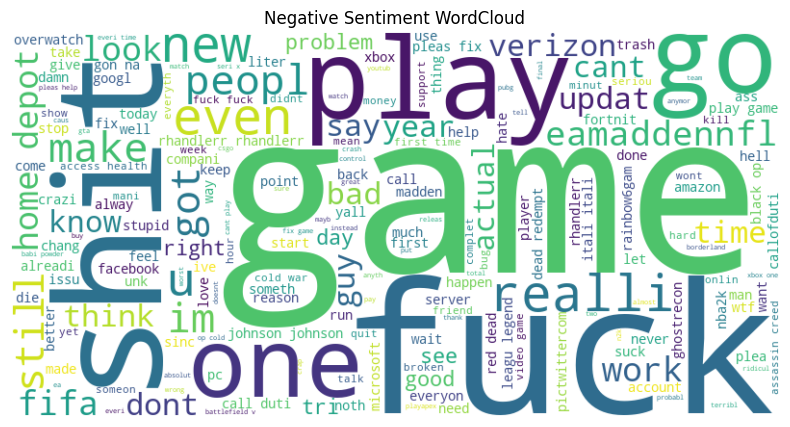

In [90]:
# Negative 
negative_text = " ".join(
    df[df["sentiment"] == "Negative"]["clean_text"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Sentiment WordCloud")
plt.show()

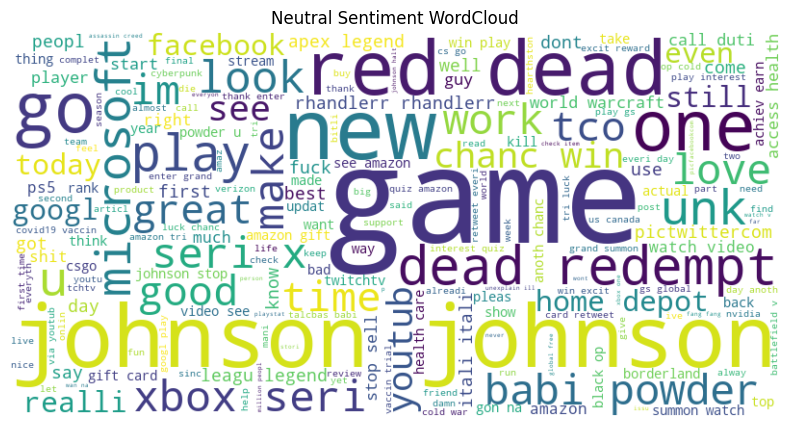

In [94]:
# Neutral 
neutral_text = " ".join(
    df[df["sentiment"] == "Neutral"]["clean_text"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(neutral_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Neutral Sentiment WordCloud")
plt.show()

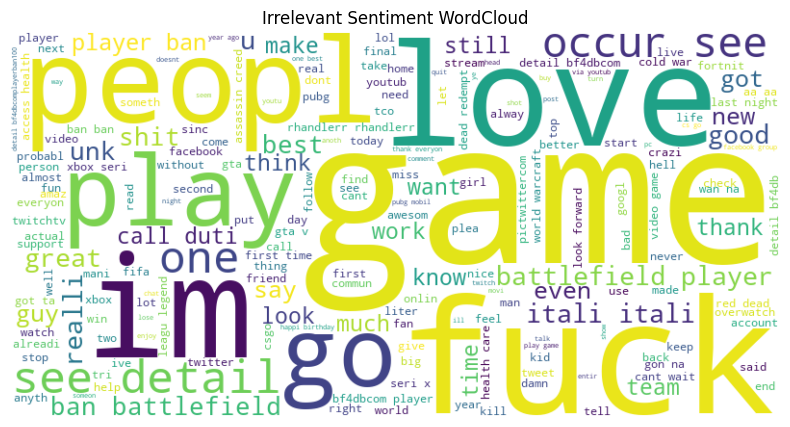

In [98]:
# Irrelevant 
irrelevant_text = " ".join(
    df[df["sentiment"] == "Irrelevant"]["clean_text"]
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(irrelevant_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Irrelevant Sentiment WordCloud")
plt.show()

In [102]:
if lr_f1 >= nb_f1:
    best_model = lr_model
    best_pred = lr_pred
    best_model_name = "Logistic Regression"
else:
    best_model = nb_model
    best_pred = nb_pred
    best_model_name = "Naive Bayes"

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [106]:
error_df = pd.DataFrame({
    "text": df.loc[y_test.index, "text"],
    "actual": y_test,
    "predicted": best_pred
})

error_df = error_df[
    error_df["actual"] != error_df["predicted"]
]

In [107]:
error_df.head(5)

,text,actual,predicted
60101,Real Real.,Irrelevant,Positive
9819,"Not unheard of, honestly. The concern I would ...",Negative,Positive
61700,The number of people begging for money from mo...,Irrelevant,Negative
12692,Thrush,Negative,Neutral
67344,@JNJCares good Luck! Hope lives go before prof...,Negative,Neutral


# Model Limitations:
# - Sarcasm or irony may be difficult to detect.
# - Mixed positive and negative opinions can cause misclassification.
# - Short or unclear text may reduce prediction accuracy.
# - Words can have different meanings depending on the context.
# - Distinguishing between Neutral and Irrelevant tweets can be challenging.

# Conclusion:
# - The model classified Twitter data into Positive, Negative, Neutral, and Irrelevant categories.
# - TF-IDF was used to convert text into numerical features.
# - Naive Bayes and Logistic Regression models were trained and evaluated.
# - Accuracy, precision, recall, F1-score, and confusion matrices were used for evaluation.
# - The model with the higher F1-score performed better on this dataset.
# - Sentiment analysis can be used for:
#   - Customer feedback analysis
#   - Social media monitoring
#   - Product review analysis
#   - Brand analysis
#   - Public opinion analysis